# Prediction of Peptide–Major Histocompatibility Complex Class I Interaction

by Salomon Marquez

01/04/2025 

In this project, we’ll explore an analysis focused on modeling the interaction between major histocompatibility complex class I (MHCI) molecules and peptides.

In cancer immunotherapy, the activation of T cells depends on their exposure to tumor peptides bound to MHCI (pMHCI). By studying the tumor’s genetics, we can identify the most relevant peptides and, based on the specific MHCI type a patient carries, predict which peptide–MHCI (pMHCI) interactions are most likely to occur in their tumor. This, in turn, helps us determine which pMHCI combinations should be used to effectively activate the patient’s T cells.

We will implement a k-NN classification algorithm to predict whether a peptide sequence interacts with MHCI or not. Moreover, we will compare the classification results obtained using two peptide representation techniques: one-hot encoding and substitution matrix transformation (BLOSUM62).

Visit the <i class="fa-brands fa-github"></i> [repository of the project](https://github.com/sblaizerwize/My-Professional-Portfolio/tree/main/docs/machine-learning/peptide%E2%80%93mhci-interaction-prediction) to check out:  

- <i class="fas fa-file-csv"></i> Peptide data
- <i class="fab fa-google"></i> Colab notebook 

---

## 1 The kNN Algorithm

According to the literature, the k-Nearest Neighbors (k-NN) algorithm is considered the simplest in the field of machine learning. This is because it is quite straightforward in its operation: there is no actual training process, as the model simply stores the data and, when a prediction is needed, searches for the k closest points within the training set.  

For example, if k = 1, the algorithm simply assigns the class of the nearest neighbor. If k is larger, the algorithm counts how many of those k neighbors belong to each class and assigns the most frequent one. This method works well for classification problems with any number of classes and can also be applied to regression problems.  

Although it is easy to understand and implement, it is not the most efficient with large volumes of data, since each prediction requires calculating multiple distances. Its performance also depends on the choice of k and how the distance between points is measured.  

The following table presents some key concepts about the kNN algorithm extracted from `Müller, A. C., & Guido, S. (2016) Introduction to Machine Learning with Python: A Guide for Data Scientists. Sebastopol, CA: O’Reilly Media, pg 44`.  

| **Strengths** | **Weaknesses** |
|---------------|----------------|
| **Easy to understand**: The model is intuitive and simple to explain. | **Slow at prediction**: Can be inefficient with large datasets, as prediction requires calculating distances with all points. |
| **Requires little tuning**: Works reasonably well with standard values (e.g., k=3 or k=5) and uses Euclidean distance by default, which is often suitable. | **Not effective with high-dimensional data**: Its performance decreases if there are many features (hundreds or more). |
| **Fast to train**: Building the model is very quick since there is no real training process, only data storage. | **Poor with sparse data**: If most of the dataset values are 0, its performance is deficient. |

## 2 Exploratory Data Analysis (EDA)
In this section, we will address some general questions about the `peptidos.csv` dataset.  

### 2.1 Reading data 

In [ ]:
# Establecer directorio de trabajo en Gdrive
import os
os.chdir("/content/drive/MyDrive/ASIGNATURAS/M0.163 MACHINE LEARNING/[19 FEB - 01 ABR] RETO 1/PEC1")

In [ ]:
# Visualizar contenido del directorio de trabajo
!ls

BLOSUM62_probabilities.csv  PEC1_EDA.ipynb  peptidos_transf_BLOSUM62.csv
enunciat_pec1_4_2425_2.pdf  peptidos.csv    peptidos_transf_one_hot.csv


In [ ]:
# Importar modulos y librerías de trabajo
import numpy as np
import pandas as pd

In [ ]:
# Guardar en un dataframe el contenido de peptidos.csv
df_peptidos = pd.read_csv("peptidos.csv", delimiter=';')

In [ ]:
# Visualizar contenido del dataframe peptidos
df_peptidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15840 entries, 0 to 15839
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sequence  15840 non-null  object
 1   label     15840 non-null  object
dtypes: object(2)
memory usage: 247.6+ KB


In [ ]:
# Visualizar las 5 primeras filas
df_peptidos.head(5)

,sequence,label
0,LMAFYLYEV,SB
1,HQRLAPTMP,NB
2,FMNGHTHIA,SB
3,WLLIFHHCP,NB
4,MRYRVSVHP,NB


In [ ]:
# Visualizar las 5 últimas filas
df_peptidos.tail(5)

,sequence,label
15835,LMWGSHVQL,SB
15836,FQDDQTMSM,SB
15837,QTYDEIHYV,SB
15838,KVFDDELWI,SB
15839,YLMVNDYWA,SB


### 2.2 How many unique sequences are in the dataset? 

In [ ]:
df_peptidos_unique = df_peptidos['sequence'].nunique()
df_peptidos_unique

15840

This result shows that there are no repeated sequences. 

### 2.3 How many types of labels exist? 

In [ ]:
df_peptidos_label = df_peptidos['label'].value_counts()
df_peptidos_label

,count
label,
SB,7920
NB,7920


This suggests that we have a symmetric dataset with an equal number of positive and negative labels.  

### 2.4 What is the length of the peptides?  

In [ ]:
# Obtener la longitud de cada péptido y ordenar en orden descendente
df_peptidos['sequence_len'] = df_peptidos['sequence'].apply(lambda x: len(x))
df_peptidos.sort_values(by='sequence_len', ascending=False)

,sequence,label,sequence_len
15823,QWGDTQGRM,NB,9
15822,FAKHYFYTA,NB,9
15821,YMFMVEMFM,SB,9
15820,PDSVNRDCH,NB,9
15819,TDYTQSNQE,NB,9
...,...,...,...
4,MRYRVSVHP,NB,9
3,WLLIFHHCP,NB,9
2,FMNGHTHIA,SB,9
1,HQRLAPTMP,NB,9


All peptides have the same length of 9 amino acids.  

## 3 Implementing the One-Hot Encoding Function

In [ ]:
# Visualizar archivos del directorio de trabajo
!ls

BLOSUM62_probabilities.csv  PEC1_EDA.ipynb  peptidos_transf_BLOSUM62.csv
enunciat_pec1_4_2425_2.pdf  peptidos.csv    peptidos_transf_one_hot.csv


In [ ]:
# Echar un vistazo al tipo de encoding que se busca
df_peptidos_encoded = pd.read_csv('peptidos_transf_one_hot.csv', delimiter = ';')
df_peptidos_encoded.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
# Obtener información del dataframe
df_peptidos_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15840 entries, 0 to 15839
Columns: 180 entries, V1 to V180
dtypes: int64(180)
memory usage: 21.8 MB


Below is a summary of the data contained in the file `peptidos_transf_one_hot.csv`:  
- The total number of sequences is 15,840 peptides. These sequences are composed of amino acids.  
- The list of standard amino acids consists of 20, including `ACDEFGHIKLMNPQRSTVWY`.  
- The length of each sequence is 9 amino acids.  
- Each sequence is encoded into a binary vector of 180 elements in length.  

It follows that the length of each binary vector results from the product of 9 (sequence length) × 20 (number of standard amino acids) = 180.  

The interpretation of one-hot encoding for peptides is as follows: each amino acid is represented as a binary vector of 20 elements. For sequences of 9 amino acids, these are concatenated in positional order. The result is a unique vector of 180 elements (9 × 20), where each block of 20 digits encodes an amino acid in its original position.  

To implement the one-hot encoding function, the `OneHotEncoder()` from the `sklearn` package will be used. The methodology will be:  

- Verify the encoder with a single sequence (one peptide).  
- Encode all peptide sequences.  
- Implement a function to perform one-hot encoding. 

### 3.1 Test encoder with a single sequence (one peptide) 

In [ ]:
# Cargar módulos y librerías
from sklearn.preprocessing import OneHotEncoder

# Crear una lista de aminoácidos que representará el diccionario de los 20 aminoácidos
amino_acidos = list('ARNDCQEGHILKMFPSTWYV')

# Crear el one-hot encoder para el diccionario de 20 aminoácidos
encoder = OneHotEncoder(categories = [amino_acidos])
encoder

OneHotEncoder(categories=[['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
                           'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']])

In [ ]:
# Definir una secuencia 'LMAFYLYEV'
secuencia = 'LMAFYLYEV'

# Convertir la secuencia en una lista
secuencia_lista = [list(secuencia)]
secuencia_lista

[['L', 'M', 'A', 'F', 'Y', 'L', 'Y', 'E', 'V']]

In [ ]:
# Convertir la secuencia en un array
# ya que fit_transform() espera un array de (n_samples, n_features)
secuencia_array = np.array(secuencia_lista)
secuencia_array

array([['L', 'M', 'A', 'F', 'Y', 'L', 'Y', 'E', 'V']], dtype='<U1')

In [ ]:
# Revisar las dimensiones del array
secuencia_array.shape

(1, 9)

In [ ]:
# Ajustar las dimensiones del array para que fit_transform() pueda codificarlo
# En este caso buscamos (n_samples, 1)
secuencia_array_reshaped = secuencia_array.reshape(-1,1)
secuencia_array_reshaped.shape

(9, 1)

In [ ]:
secuencia_array_reshaped

array([['L'],
       ['M'],
       ['A'],
       ['F'],
       ['Y'],
       ['L'],
       ['Y'],
       ['E'],
       ['V']], dtype='<U1')

In [ ]:
# Codificar secuencia usando el codificador one-hot
secuencia_array_encoded = encoder.fit_transform(secuencia_array_reshaped)
secuencia_array_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (9, 20)>

In [ ]:
# Convertir a array la matriz CSR para visualizar su contenido
encoded_array = secuencia_array_encoded.toarray()
print(encoded_array)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


Each row of the array corresponds to the encoding of one amino acid from the 9 that make up the sequence `LMAFYLYEV`.  

### 3.2 Encode all peptide sequences
Once the functionality of the one-hot encoder for a single sequence has been verified, we proceed to convert all 15,840 peptide sequences.  

In [ ]:
# Separar los aminoácidos de cada secuencia de péptidos y generar una lista
sequences_splitted = [list(seq) for seq in df_peptidos['sequence']]
# Visualizar los primeros 5 elementos
sequences_splitted[:5]

[['L', 'M', 'A', 'F', 'Y', 'L', 'Y', 'E', 'V'],
 ['H', 'Q', 'R', 'L', 'A', 'P', 'T', 'M', 'P'],
 ['F', 'M', 'N', 'G', 'H', 'T', 'H', 'I', 'A'],
 ['W', 'L', 'L', 'I', 'F', 'H', 'H', 'C', 'P'],
 ['M', 'R', 'Y', 'R', 'V', 'S', 'V', 'H', 'P']]

In [ ]:
# Verificar el tipo de dato
type(sequences_splitted)

list

In [ ]:
# Convertir la lista de aminoácidos en un array
sequences_array = np.array(sequences_splitted)
# Visualizar las dimensiones del array
sequences_array.shape

(15840, 9)

In [ ]:
# Para eliminar el "ValueError: Expected 2D array, got 1D array instead"
# al momento de la codificación con el one-hot encoder
# Reajustar la dimensiones del array
sequences_array_reshaped = sequences_array.reshape(-1, 1)
# Visualizar las dimensiones del array
sequences_array_reshaped.shape

(142560, 1)

In [ ]:
# Codificar secuencias usando el codificador one-hot
df_peptidos_onehot_encoded = encoder.fit_transform(sequences_array_reshaped)

In [ ]:
# Convertir a array la matriz CSR para visualizar su contenido
df_peptidos_onehot_encoded_array = df_peptidos_onehot_encoded.toarray()
# Visualizar las primeras 10 secuencias codificadas
print(df_peptidos_onehot_encoded_array[:10])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
# Verificar las dimensiones del array
df_peptidos_onehot_encoded_array.shape

(142560, 20)

In [ ]:
# Reajustar las dimensiones del array de (142560, 20) a (15840, 180)
# esto para tener la codificación de cada secuencia de 9 péptidos completa
onehot_reshaped = df_peptidos_onehot_encoded_array.reshape(len(df_peptidos), -1)
onehot_reshaped.shape

(15840, 180)

In [ ]:
# Visualizar la primer secuencia
df_peptidos['sequence'][0]

'LMAFYLYEV'

In [ ]:
# Visualizar el primer registro
onehot_reshaped[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

Comparing the first record of the array `onehot_reshaped` with the corresponding record in the file `peptidos_transf_one_hot.csv`, we observe the same one-hot encoding.  

### 3.3 Implementing the function `one_hot_encoder()`  
Once the one-hot encoder functionality is understood, we implement a custom function that directly transforms peptide sequences read from a `csv` file.  

In [ ]:
# Cargar módulos y librerías
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Definir función one_hot_encoder()
def one_hot_encoder(col_peptidos):
  """
  Objetivo: Implementa una codificación one-hot
  Argumentos: col_peptidos (pandas.series)  : Datos correspondientes a las secuencias de péptidos
  Regresa:  col_peptidos_encoded (np.array) : Datos codificados con one-hot
  """
  # Separar los aminoácidos de cada secuencia de péptidos y generar una lista
  sequences_splitted = [list(seq) for seq in col_peptidos]

  # Convertir la lista de aminoácidos en un array
  sequences_array = np.array(sequences_splitted)

  # Reajustar la dimensiones del array
  sequences_array_reshaped = sequences_array.reshape(-1, 1)

  # Codificar secuencias
  df_peptidos_onehot_encoded = encoder.fit_transform(sequences_array_reshaped)

  # Convertir a array la matriz CSR resultante de la codificación one-hot
  df_peptidos_onehot_encoded_array = df_peptidos_onehot_encoded.toarray()

  # Reajustar las dimensiones del array a (n_samples, len_peptidos x len_diccionario_peptidos)
  col_peptidos_encoded = df_peptidos_onehot_encoded_array.reshape(len(col_peptidos), -1)

  return col_peptidos_encoded

In [ ]:
# Comprobar el funcionamiento de one_hot_encoder()
peptidos_encoded = one_hot_encoder(df_peptidos['sequence'])
peptidos_encoded.shape

(15840, 180)

In [ ]:
# Visualizar el primer registro codificado
peptidos_encoded[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

##  4 Implementing an Encoding Function Based on a Substitution Matrix 

Unlike one-hot encoding, the substitution matrix encoder will be implemented from scratch using the substitution matrix provided in the file `BLOSUM62_probabilities.csv`. The development of this function includes the following steps:  

- Explore the file `BLOSUM62_probabilities.csv`.  
- Encode the first amino acid (L) of the sequence `LMAFYLYEV`.  
- Encode the entire sequence `LMAFYLYEV`.  
- Encode all sequences in the dataset.  
- Implement the function `matriz_trans_encoder()`.  

### 4.1 Explore the file `BLOSUM62_probabilities.csv` 

In [ ]:
# Consultar el directorio de trabajo
!ls

BLOSUM62_probabilities.csv  PEC1_EDA.ipynb  peptidos_transf_BLOSUM62.csv
enunciat_pec1_4_2425_2.pdf  peptidos.csv    peptidos_transf_one_hot.csv


In [ ]:
# Leer el archivo BLOSUM62_probabilities
blosum62prob_df = pd.read_csv("BLOSUM62_probabilities.csv", delimiter=';', dtype=str)

In [ ]:
# Obtener información del dataframe
blosum62prob_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  20 non-null     object
 1   A           20 non-null     object
 2   R           20 non-null     object
 3   N           20 non-null     object
 4   D           20 non-null     object
 5   C           20 non-null     object
 6   Q           20 non-null     object
 7   E           20 non-null     object
 8   G           20 non-null     object
 9   H           20 non-null     object
 10  I           20 non-null     object
 11  L           20 non-null     object
 12  K           20 non-null     object
 13  M           20 non-null     object
 14  F           20 non-null     object
 15  P           20 non-null     object
 16  S           20 non-null     object
 17  T           20 non-null     object
 18  W           20 non-null     object
 19  Y           20 non-null     object
 20  V           

In [ ]:
# Renombrar la columna sin nombre
blosum62prob_df = blosum62prob_df.rename(columns = {"Unnamed: 0":"Aminoacidos"})
blosum62prob_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Aminoacidos  20 non-null     object
 1   A            20 non-null     object
 2   R            20 non-null     object
 3   N            20 non-null     object
 4   D            20 non-null     object
 5   C            20 non-null     object
 6   Q            20 non-null     object
 7   E            20 non-null     object
 8   G            20 non-null     object
 9   H            20 non-null     object
 10  I            20 non-null     object
 11  L            20 non-null     object
 12  K            20 non-null     object
 13  M            20 non-null     object
 14  F            20 non-null     object
 15  P            20 non-null     object
 16  S            20 non-null     object
 17  T            20 non-null     object
 18  W            20 non-null     object
 19  Y            20 non-null     ob

In [ ]:
# Visualizar los primeros 5 elementos
blosum62prob_df.head(5)

,Aminoacidos,A,R,N,D,C,Q,E,G,H,...,L,K,M,F,P,S,T,W,Y,V
0,A,"0,29015","0,03104","0,02564","0,02969","0,02159","0,02564","0,04049","0,07827","0,01484",...,"0,05938","0,04453","0,01754","0,02159","0,02969","0,08502","0,04993","0,0054","0,01754","0,06883"
1,R,"0,04457","0,34496","0,03876","0,03101","0,00775","0,04845","0,05233","0,03295","0,02326",...,"0,04651","0,12016","0,0155","0,01744","0,01938","0,04457","0,03488","0,00581","0,01744","0,03101"
2,N,"0,0427","0,04494","0,31685","0,08315","0,00899","0,03371","0,04944","0,06517","0,03146",...,"0,03146","0,05393","0,01124","0,01798","0,02022","0,06966","0,04944","0,00449","0,01573","0,02697"
3,D,"0,04104","0,02985","0,06903","0,39739","0,00746","0,02985","0,09142","0,04664","0,01866",...,"0,02799","0,04478","0,00933","0,01493","0,02239","0,05224","0,03545","0,00373","0,01119","0,02425"
4,C,"0,06504","0,01626","0,01626","0,01626","0,48374","0,0122","0,01626","0,03252","0,00813",...,"0,06504","0,02033","0,01626","0,02033","0,01626","0,04065","0,03659","0,00407","0,0122","0,05691"


We observe that each amino acid has a probability representation based on a dictionary of the 20 existing amino acids. However, the values in the dataframe are of type `string` and use a comma as the decimal separator. It is necessary to replace the decimal separator with a dot and ensure that values are converted to `float`.

In [ ]:
# Convertir una columna específica substituyendo el separador decimal
# y conviertiendo el dato a tipo float
blosum62prob_df["A"] = blosum62prob_df["A"].str.replace(",", ".").astype(float)
blosum62prob_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Aminoacidos  20 non-null     object 
 1   A            20 non-null     float64
 2   R            20 non-null     object 
 3   N            20 non-null     object 
 4   D            20 non-null     object 
 5   C            20 non-null     object 
 6   Q            20 non-null     object 
 7   E            20 non-null     object 
 8   G            20 non-null     object 
 9   H            20 non-null     object 
 10  I            20 non-null     object 
 11  L            20 non-null     object 
 12  K            20 non-null     object 
 13  M            20 non-null     object 
 14  F            20 non-null     object 
 15  P            20 non-null     object 
 16  S            20 non-null     object 
 17  T            20 non-null     object 
 18  W            20 non-null     object 
 19  Y         

In [ ]:
# Convertir el resto de colummnas a partir de la 2da columna
for col in blosum62prob_df.columns[2:]:
    blosum62prob_df[col] = blosum62prob_df[col].str.replace(",", ".").astype(float)
blosum62prob_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Aminoacidos  20 non-null     object 
 1   A            20 non-null     float64
 2   R            20 non-null     float64
 3   N            20 non-null     float64
 4   D            20 non-null     float64
 5   C            20 non-null     float64
 6   Q            20 non-null     float64
 7   E            20 non-null     float64
 8   G            20 non-null     float64
 9   H            20 non-null     float64
 10  I            20 non-null     float64
 11  L            20 non-null     float64
 12  K            20 non-null     float64
 13  M            20 non-null     float64
 14  F            20 non-null     float64
 15  P            20 non-null     float64
 16  S            20 non-null     float64
 17  T            20 non-null     float64
 18  W            20 non-null     float64
 19  Y         

The goal of the substitution matrix–based transformation is to produce an array that represents X (input data for the kNN model) with a structure similar to that of the one-hot encoder, but where each `0` or `1` value is replaced by a probability.  

```
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
```

### 4.2 Encoding the first amino acid (L) of the sequence `LMAFYLYEV`
We will start with a simple example, encoding the first amino acid `L` of the sequence `LMAFYLYEV`.

In [ ]:
# Codificar la siguiente secuencia usando el método de la matriz de substitución
secuencia = 'LMAFYLYEV'

In [ ]:
# Seleccionar de la matriz `blosum62prob_df` los valores de probabilidades correspondientes
# al primer aminoácidos 'L' de la secuencia 'LMAFYLYEV'. Y eliminar parcialmente
# la columna 'Aminoacidos' para solo considerar las probabilidades
amino_L = blosum62prob_df[blosum62prob_df['Aminoacidos'] == 'L'].drop(columns=['Aminoacidos'])
amino_L

,A,R,N,D,C,Q,E,G,H,I,L,K,M,F,P,S,T,W,Y,V
10,0.04453,0.02429,0.01417,0.01518,0.01619,0.01619,0.02024,0.02126,0.01012,0.11538,0.37551,0.0253,0.0496,0.05466,0.01417,0.02429,0.0334,0.00709,0.02227,0.09615


In [ ]:
# Convertir de pandas.Series a un array de Numpy
amino_L_array = amino_L.to_numpy()

In [ ]:
# Visualizar las probabilidades del aminoácido 'L'
amino_L_array[0]

array([0.04453, 0.02429, 0.01417, 0.01518, 0.01619, 0.01619, 0.02024,
       0.02126, 0.01012, 0.11538, 0.37551, 0.0253 , 0.0496 , 0.05466,
       0.01417, 0.02429, 0.0334 , 0.00709, 0.02227, 0.09615])

### 4.3 Encoding the sequence `LMAFYLYEV`
We will now continue with the rest of the sequence `LMAFYLYEV`.

In [ ]:
# Crear un diccionario que contenga como key el aminoácido y como valor un array de sus probabilidades
amino_list = 'ARNDCQEGHILKMFPSTWYV'
amino_dict = {}

for amino in amino_list:
  amino_series      = blosum62prob_df[blosum62prob_df['Aminoacidos'] == amino].drop(columns=['Aminoacidos'])
  amino_array       = amino_series.to_numpy()
  amino_dict[amino] = amino_array[0]

In [ ]:
# Visualizar el diccionario de aminoacidos
amino_dict

{'A': array([0.29015, 0.03104, 0.02564, 0.02969, 0.02159, 0.02564, 0.04049,
        0.07827, 0.01484, 0.04318, 0.05938, 0.04453, 0.01754, 0.02159,
        0.02969, 0.08502, 0.04993, 0.0054 , 0.01754, 0.06883]),
 'R': array([0.04457, 0.34496, 0.03876, 0.03101, 0.00775, 0.04845, 0.05233,
        0.03295, 0.02326, 0.02326, 0.04651, 0.12016, 0.0155 , 0.01744,
        0.01938, 0.04457, 0.03488, 0.00581, 0.01744, 0.03101]),
 'N': array([0.0427 , 0.04494, 0.31685, 0.08315, 0.00899, 0.03371, 0.04944,
        0.06517, 0.03146, 0.02247, 0.03146, 0.05393, 0.01124, 0.01798,
        0.02022, 0.06966, 0.04944, 0.00449, 0.01573, 0.02697]),
 'D': array([0.04104, 0.02985, 0.06903, 0.39739, 0.00746, 0.02985, 0.09142,
        0.04664, 0.01866, 0.02239, 0.02799, 0.04478, 0.00933, 0.01493,
        0.02239, 0.05224, 0.03545, 0.00373, 0.01119, 0.02425]),
 'C': array([0.06504, 0.01626, 0.01626, 0.01626, 0.48374, 0.0122 , 0.01626,
        0.03252, 0.00813, 0.04472, 0.06504, 0.02033, 0.01626, 0.02033,
        0

In [ ]:
# Usar un list comprehension para codificar la secuencia 'LMAFYLYEV'
seq_array = np.array([amino_dict[amino] for amino in secuencia])
seq_array

array([[0.04453, 0.02429, 0.01417, 0.01518, 0.01619, 0.01619, 0.02024,
        0.02126, 0.01012, 0.11538, 0.37551, 0.0253 , 0.0496 , 0.05466,
        0.01417, 0.02429, 0.0334 , 0.00709, 0.02227, 0.09615],
       [0.05221, 0.03213, 0.02008, 0.02008, 0.01606, 0.02811, 0.02811,
        0.02811, 0.01606, 0.1004 , 0.19679, 0.03614, 0.16064, 0.04819,
        0.01606, 0.03614, 0.04016, 0.00803, 0.0241 , 0.09237],
       [0.29015, 0.03104, 0.02564, 0.02969, 0.02159, 0.02564, 0.04049,
        0.07827, 0.01484, 0.04318, 0.05938, 0.04453, 0.01754, 0.02159,
        0.02969, 0.08502, 0.04993, 0.0054 , 0.01754, 0.06883],
       [0.03383, 0.01903, 0.01691, 0.01691, 0.01057, 0.01057, 0.01903,
        0.02537, 0.01691, 0.06342, 0.11416, 0.01903, 0.02537, 0.38689,
        0.01057, 0.02537, 0.02537, 0.01691, 0.08879, 0.05497],
       [0.0405 , 0.02804, 0.02181, 0.01869, 0.00935, 0.02181, 0.02804,
        0.02492, 0.04673, 0.04361, 0.06854, 0.03115, 0.01869, 0.13084,
        0.01558, 0.03115, 0.02804, 0.0

### 4.4 Encoding all sequences in the dataset
In this section, we reuse the code we used for the implementation of the one-hot encoder.

In [ ]:
# Separar los aminoácidos de cada secuencia de péptidos y generar una lista
sequences_splitted = [list(seq) for seq in df_peptidos['sequence']]
# Visualizar los primeros 5 elementos
sequences_splitted[:5]

[['L', 'M', 'A', 'F', 'Y', 'L', 'Y', 'E', 'V'],
 ['H', 'Q', 'R', 'L', 'A', 'P', 'T', 'M', 'P'],
 ['F', 'M', 'N', 'G', 'H', 'T', 'H', 'I', 'A'],
 ['W', 'L', 'L', 'I', 'F', 'H', 'H', 'C', 'P'],
 ['M', 'R', 'Y', 'R', 'V', 'S', 'V', 'H', 'P']]

In [ ]:
# Verificar que el tipo de dato generado sea una lista
type(sequences_splitted)

list

In [ ]:
# Convertir la lista de aminoácidos en un array
sequences_array = np.array(sequences_splitted)
# Visualizar las dimensiones del array
sequences_array.shape

(15840, 9)

In [ ]:
# Codificar el array de secuencias usando el método de matriz de substitución
# se espera como resultado un array de dimensión (15840, 180)

peptido_list = []

for seq in sequences_array:
  amino_list = []
  for amino in seq:
    amino_list.append(np.array(amino_dict[amino]))
  peptido_list.append(amino_list)

In [ ]:
 peptido_list[0]

[array([0.04453, 0.02429, 0.01417, 0.01518, 0.01619, 0.01619, 0.02024,
        0.02126, 0.01012, 0.11538, 0.37551, 0.0253 , 0.0496 , 0.05466,
        0.01417, 0.02429, 0.0334 , 0.00709, 0.02227, 0.09615]),
 array([0.05221, 0.03213, 0.02008, 0.02008, 0.01606, 0.02811, 0.02811,
        0.02811, 0.01606, 0.1004 , 0.19679, 0.03614, 0.16064, 0.04819,
        0.01606, 0.03614, 0.04016, 0.00803, 0.0241 , 0.09237]),
 array([0.29015, 0.03104, 0.02564, 0.02969, 0.02159, 0.02564, 0.04049,
        0.07827, 0.01484, 0.04318, 0.05938, 0.04453, 0.01754, 0.02159,
        0.02969, 0.08502, 0.04993, 0.0054 , 0.01754, 0.06883]),
 array([0.03383, 0.01903, 0.01691, 0.01691, 0.01057, 0.01057, 0.01903,
        0.02537, 0.01691, 0.06342, 0.11416, 0.01903, 0.02537, 0.38689,
        0.01057, 0.02537, 0.02537, 0.01691, 0.08879, 0.05497]),
 array([0.0405 , 0.02804, 0.02181, 0.01869, 0.00935, 0.02181, 0.02804,
        0.02492, 0.04673, 0.04361, 0.06854, 0.03115, 0.01869, 0.13084,
        0.01558, 0.03115, 0.02804,

In [ ]:
# Convertir la lista de aminoácidos en un array
total_sequences_array = np.array(peptido_list)
# Visualizar las dimensiones del array
total_sequences_array.shape

(15840, 9, 20)

In [ ]:
# Reajustar las dimensiones del array para que coincidan con las deseadas (15840, 180)
total_sequences_array_reshaped = total_sequences_array.reshape(15840, 180)

In [ ]:
# Visualizar el primer registro
total_sequences_array_reshaped[0]

array([0.04453, 0.02429, 0.01417, 0.01518, 0.01619, 0.01619, 0.02024,
       0.02126, 0.01012, 0.11538, 0.37551, 0.0253 , 0.0496 , 0.05466,
       0.01417, 0.02429, 0.0334 , 0.00709, 0.02227, 0.09615, 0.05221,
       0.03213, 0.02008, 0.02008, 0.01606, 0.02811, 0.02811, 0.02811,
       0.01606, 0.1004 , 0.19679, 0.03614, 0.16064, 0.04819, 0.01606,
       0.03614, 0.04016, 0.00803, 0.0241 , 0.09237, 0.29015, 0.03104,
       0.02564, 0.02969, 0.02159, 0.02564, 0.04049, 0.07827, 0.01484,
       0.04318, 0.05938, 0.04453, 0.01754, 0.02159, 0.02969, 0.08502,
       0.04993, 0.0054 , 0.01754, 0.06883, 0.03383, 0.01903, 0.01691,
       0.01691, 0.01057, 0.01057, 0.01903, 0.02537, 0.01691, 0.06342,
       0.11416, 0.01903, 0.02537, 0.38689, 0.01057, 0.02537, 0.02537,
       0.01691, 0.08879, 0.05497, 0.0405 , 0.02804, 0.02181, 0.01869,
       0.00935, 0.02181, 0.02804, 0.02492, 0.04673, 0.04361, 0.06854,
       0.03115, 0.01869, 0.13084, 0.01558, 0.03115, 0.02804, 0.02804,
       0.31776, 0.04

And as a result, we obtain the mutation probability vector for the first record, just as it appears in the PEC1 description.

### 4.5 Implementing the `matriz_trans_encoder()` function
This function will compile all the steps from section 4.4 to create a function that performs encoding based on a substitution matrix.

In [ ]:
# Definir matriz_trans_encoder()
def matriz_trans_encoder(col_peptidos, df_matriz_trans):
  """
  Objetivo: Implementa una codificación basada en una matriz de substitución
  Argumentos:
    col_peptidos (pandas.series)  : Datos correspondientes a las secuencias de péptidos
    df_matriz_trans (pandas.dataframe) : Datos correspondientes a la matriz de transformación
  Regresa:  col_peptidos_encoded (np.array) : Datos codificados con la matriz de substitución
  """

  # Preparar la matriz de substitución

  # Renombrar la columna sin nombre
  df_matriz_trans = df_matriz_trans.rename(columns = {"Unnamed: 0":"Aminoacidos"})

  # Convertir el resto de colummnas a partir de la 2da columna
  for col in df_matriz_trans.columns[1:]:
      df_matriz_trans[col] = df_matriz_trans[col].str.replace(",", ".").astype(float)


  # Preparar las secuencias de péptidos

  # Separar los aminoácidos de cada secuencia de péptidos y generar una lista
  sequences_splitted = [list(seq) for seq in col_peptidos]

  # Convertir la lista de aminoácidos en un array
  sequences_array = np.array(sequences_splitted)

  # Codificar el array de secuencias usando el método de matriz de substitución
  peptido_list = []
  for seq in sequences_array:
    amino_list = []
    for amino in seq:
      amino_list.append(np.array(amino_dict[amino]))
    peptido_list.append(amino_list)

  # Convertir la lista de aminoácidos en un array
  total_sequences_array = np.array(peptido_list)

  # Reajustar las dimensiones del array a (n_samples, len_peptidos x len_dict_peptidos)
  n_samples            = len(col_peptidos)       # Número total de secuencias de péptidos
  len_peptidos         = len(col_peptidos[0])    # Longitud de un péptido
  len_dict_peptidos, m = df_matriz_trans.shape   # Total de aminoácidos que componen en diccionario péptidos
  col_peptidos_encoded = total_sequences_array.reshape(n_samples , len_peptidos*len_dict_peptidos)

  return col_peptidos_encoded

In [ ]:
# Comprobar el funcionamiento de matriz_trans_encoder()

# Leer el archivo BLOSUM62_probabilities
blosum62prob_df = pd.read_csv("BLOSUM62_probabilities.csv", delimiter=';', dtype=str)

# Codificar todas las secuencias de péptidos
peptidos_encoded = matriz_trans_encoder(df_peptidos['sequence'], blosum62prob_df)
peptidos_encoded.shape

(15840, 180)

In [ ]:
# Visualizar el primer registro
peptidos_encoded[0]

array([0.04453, 0.02429, 0.01417, 0.01518, 0.01619, 0.01619, 0.02024,
       0.02126, 0.01012, 0.11538, 0.37551, 0.0253 , 0.0496 , 0.05466,
       0.01417, 0.02429, 0.0334 , 0.00709, 0.02227, 0.09615, 0.05221,
       0.03213, 0.02008, 0.02008, 0.01606, 0.02811, 0.02811, 0.02811,
       0.01606, 0.1004 , 0.19679, 0.03614, 0.16064, 0.04819, 0.01606,
       0.03614, 0.04016, 0.00803, 0.0241 , 0.09237, 0.29015, 0.03104,
       0.02564, 0.02969, 0.02159, 0.02564, 0.04049, 0.07827, 0.01484,
       0.04318, 0.05938, 0.04453, 0.01754, 0.02159, 0.02969, 0.08502,
       0.04993, 0.0054 , 0.01754, 0.06883, 0.03383, 0.01903, 0.01691,
       0.01691, 0.01057, 0.01057, 0.01903, 0.02537, 0.01691, 0.06342,
       0.11416, 0.01903, 0.02537, 0.38689, 0.01057, 0.02537, 0.02537,
       0.01691, 0.08879, 0.05497, 0.0405 , 0.02804, 0.02181, 0.01869,
       0.00935, 0.02181, 0.02804, 0.02492, 0.04673, 0.04361, 0.06854,
       0.03115, 0.01869, 0.13084, 0.01558, 0.03115, 0.02804, 0.02804,
       0.31776, 0.04

## 5. Preparation for the implementation of the k-Nearest Neighbors algorithm

This section is preparatory for the implementation of the kNN algorithm. It includes a brief analysis of the contents of the `peptidos.csv` file and a description of its representation using sequence logos. This section includes:

- Reading the `peptidos.csv` file
- Representing the peptide sequence logos
- Preparing the `labels` for the peptidos dataset

### 5.1 Read the `peptidos.csv` file
As was done in the Exploratory Data Analysis (EDA) section, a brief description of the peptidos dataset is included, as suggested by the PEC1 instructions.

In [ ]:
# Guardar en un dataframe el contenido de peptidos.csv
df_peptidos = pd.read_csv("peptidos.csv", delimiter=';')

In [ ]:
# Identificar el número de observaciones por clase
df_peptidos_label = df_peptidos['label'].value_counts()
df_peptidos_label

,count
label,
SB,7920
NB,7920


### 5.2 Represent the peptide sequence logos
To represent the peptides in their sequence logo form, we will use the `logomaker` library, taking the notebook [Logos from alignment](https://github.com/jbkinney/logomaker/blob/master/logomaker/tutorials/2_logos_from_alignment.ipynb) as a reference.

In [ ]:
# Instalar logomaker
!pip install logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 53.2 MB/s eta 0:00:00


In [ ]:
# Importar modulos y librerias de logomaker
import matplotlib.pyplot as plt
%matplotlib inline
plt.ion()

import logomaker as lm

In [ ]:
# Usar el método alignment_to_matrix() de logomaker para generar un dataframe de cuentas
mat_cuentas = lm.alignment_to_matrix(df_peptidos['sequence'])
mat_cuentas.head()

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
pos,,,,,,,,,,,,,,,,,,,,
0,907,463,398,421,1507,873,697,867,928,737,815,638,413,591,823,942,714,822,701,1583
1,441,392,417,431,394,396,430,1221,389,3826,2699,435,385,854,414,450,525,928,426,387
2,855,490,1003,538,1183,654,670,979,483,914,1194,788,639,601,420,708,572,728,1193,1228
3,830,496,1512,1468,623,1046,734,596,711,548,567,906,1162,726,601,817,717,552,611,617
4,749,495,953,863,899,1018,901,931,687,710,627,782,858,759,654,709,676,868,804,897


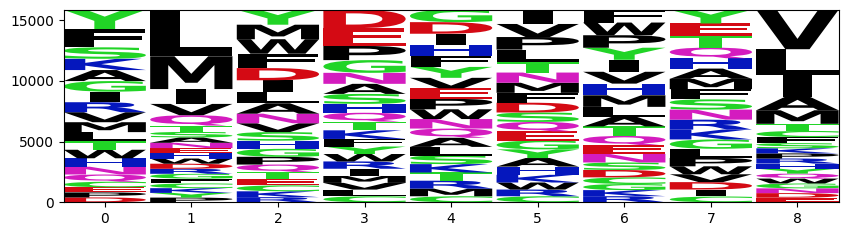

In [ ]:
# Generar el diagrama de secuencia de logo a partir del dataframe de cuentas
lm.Logo(mat_cuentas)

in validate_matrix(): Row sums in df are not close to 1. Reormalizing rows...


/usr/local/lib/python3.11/dist-packages/logomaker/src/validate.py:123: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0572601  0.02784091 0.05397727 0.05239899 0.04728535 0.04450758
 0.05025253 0.05353535 0.0707702 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, :] = df.values / sums[:, np.newaxis]
/usr/local/lib/python3.11/dist-packages/logomaker/src/validate.py:123: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0292298  0.02474747 0.03093434 0.03131313 0.03125    0.03137626
 0.03453283 0.03005051 0.03194444]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, :] = df.values / sums[:, np.newaxis]
/usr/local/lib/python3.11/dist-packages/logomaker/src/validate.py:123: FutureWarning: Setting an item of incompatible dtype is deprecated and wi

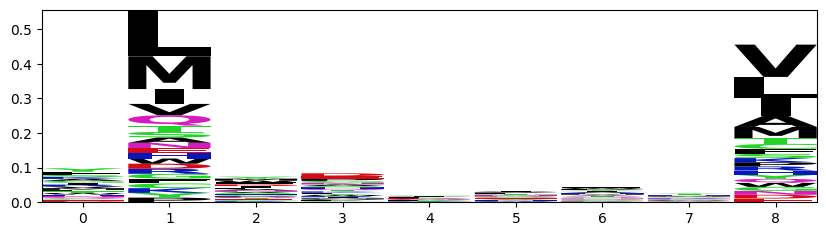

In [ ]:
# Convertir la matriz de cuentas a una matriz de bits
mat_bits = lm.transform_matrix(mat_cuentas, from_type='probability', to_type='information')

# Crear secuencias logo a partir de la matriz de bits
lm.Logo(mat_bits)

**Comments on sequence logos:**

The sequence logo analysis reveals that bits 1 and 8 are the most critical in the study of peptide-MHCI interaction, with bit 1 standing out as the most conserved site (above 0.5), dominated by hydrophobic amino acids (L, M, I, V). The other bits (less than 0.1) are of little relevance, showing variable positions. Overall, these patterns point to a well-defined functional domain in bits 1 and 8, where mutations in bit 1 (especially in Leucine) would be very interesting to analyze.

### 5.3 Prepare the labels for the `peptidos` dataset
The `Label` variable in the `peptidos` dataset has two values, SB and NB, where SB is considered the positive category. Therefore, it is necessary to convert this variable into a binary format where SB = 1 and NB = 0.

In [ ]:
# Convertir label en binario
label_binario = df_peptidos['label'].apply(lambda x: 1 if x == 'SB' else 0)

# Visualizar los primeros 5 elementos
label_binario[:5]

,label
0,1
1,0
2,1
3,0
4,0


In [ ]:
# Identicar el tipo de variable Label
type(label_binario)

pandas.core.series.Series

In [ ]:
# Convertir de pandas.Series a un array de Numpy
label_array = label_binario.to_numpy()

In [ ]:
# Visualizar los primeros 5 elementos del array
label_array[:5]

array([1, 0, 1, 0, 0])

---

## 6. Implementation of the kNN algorithm using one-hot encoded data

This section describes the step-by-step implementation of the kNN algorithm using one-hot encoded data, through four main tasks:

- Implementing kNN for k = 3
- Presenting the results of the kNN algorithm for k = 3
- Implementing the `modelo_knn_ks()` function, which computes the kNN algorithm for k = 3, 5, 7, and 11
- Presenting the results of the kNN algorithm for k = 3, 5, 7, and 11

### 6.1 Implement kNN for k = 3

In [ ]:
# Cargar librerías del modelo k-nn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
# Comprobar que las variables del dataset peptidos sean binarias y tipo array
# De la documentación de scikit se lee que fit(x,y) recibe {array-like, sparse matrix} of (n_samples, n_features)
# onehot_reshaped.shape = (15840, 180)
# labels.shape = (15840,)
print(f"La variable péptidos es de tipo {type(onehot_reshaped)} con dimensión {onehot_reshaped.shape}\n"
      f"y la variable label es de tipo {type(label_array)} con dimensión {label_array.shape}")

La variable péptidos es de tipo <class 'numpy.ndarray'> con dimensión (15840, 180)
y la variable label es de tipo <class 'numpy.ndarray'> con dimensión (15840,)


In [ ]:
# Crear train y test datasets
X_train, X_test, y_train, y_test = train_test_split(
    onehot_reshaped,
    label_array,
    test_size = 0.33, # 33% para el dataset test como lo indica el enunciado de la PEC1
    random_state= 123 # Fijamos la semilla aleatoria en 123
)

In [ ]:
# Visualizar la dimensiones de los 4 datases creados a partir de train_test_split()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10612, 180), (10612,), (5228, 180), (5228,))

In [ ]:
# Crear modelo k-nn con k = 3
k     = 3   # Valor del nearest neighbor k = [3, 5, 7, 11]
model = KNeighborsClassifier(n_neighbors=k, metric='euclidean') # Distancia euclidiana

# Entrenar modelo k-nn
model.fit(X_train, y_train)

# Hacer predicciones con el modelo k-nn entrenado usando X_test
y_pred = model.predict(X_test)

# Imprimir reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.69      0.81      2653
           1       0.76      0.99      0.86      2575

    accuracy                           0.84      5228
   macro avg       0.87      0.84      0.84      5228
weighted avg       0.87      0.84      0.84      5228



---

### 6.2 Present the results of the kNN algorithm for k = 3

To compute the following metrics, we will take into account that the positive class is `SB`:  

- Number of FPs  
- Number of FNs  
- Classification error  
- AUC value 

For the first two metrics, we will use a [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#confusion-matrix). Then, we will calculate the [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#accuracy-score) parameter to determine the classification error as `1 - accuracy`. Finally, we will rely on the `sklearn.metrics` library to compute the AUC.

In [ ]:
# Cargar módulos y librerías para calcular la matriz de confusión y la exactitud
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# Obtener la matriz de confusion
# Usar ravel() para convertir un array multidimensional en uno unidimensional
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

In [ ]:
# Calcular el error de clasificación
error = 1 - accuracy_score(y_test, y_pred)

In [ ]:
# Visualizar las métricas
print(f"Para y_test con n = {len(y_test)} se obtuvieron\n"
      f"Falsos Positivos: {fp}, Falsos Negativos: {fn}, Error de clasificación: {error:.4f}")

Para y_test con n = 5228 se obtuvieron
Falsos Positivos: 817, Falsos Negativos: 21, Error de clasificación: 0.1603


In [ ]:
# Cargar modulos y librerías para el cálculo de la curva ROC y AUC
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
# Para obtener las métricas ROC y AUC, es necesario que el modelo devuelva probabilidades
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.predict_proba
# Entonces, en lugar de devolver y_pred devolveremos y_prob
y_probs = model.predict_proba(X_test)

In [ ]:
# Comprobar que y_probs regresa las probabilidades para cada categoría
print(y_probs[:5])

[[0.         1.        ]
 [0.66666667 0.33333333]
 [0.         1.        ]
 [0.         1.        ]
 [0.         1.        ]]


In [ ]:
# Seleccionar únicamente las probabilidades para la categoría positiva
y_probs = y_probs[:,1]
print(y_probs[:10])

[1.         0.33333333 1.         1.         1.         1.
 0.         1.         0.66666667 1.        ]


In [ ]:
# Calcular curva ROC y AUC
fpr, tpr, thresholds  = roc_curve(y_test, y_probs)      # Obtenemos tasas de FPs y TPs
auc_score             = roc_auc_score(y_test, y_probs)

print(f"AUC: {auc_score:.4f}")

AUC: 0.9289


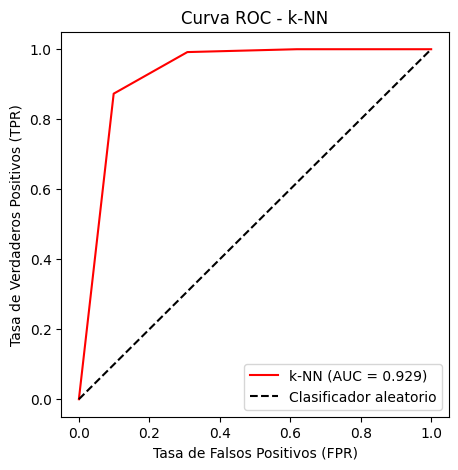

In [ ]:
# Graficar curva ROC
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'k-NN (AUC = {auc_score:.3f})', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - k-NN')
plt.legend()
plt.show()

### 6.3 Implement the function `modelo_knn_ks()` to compute the kNN algorithm for k = 3, 5, 7, and 11
To generate predictions of the kNN model based on the value of k, we create a function that performs the following main tasks:

1. Create the model  
2. Train the model  
3. Obtain predictions from the model  
4. Calculate model metrics 

The function will take as input arguments: the value of k, `X_train`, `y_train`, `X_test`, and `y_test`. As output, it will provide the following metrics: FPs, FNs, classification error, fpr, tpr, thresholds, and AUC.

In [ ]:
# Guardar en un dataframe el contenido de peptidos.csv
df_peptidos = pd.read_csv("peptidos.csv", delimiter=';')

In [ ]:
# Aplicar codificación one-hot a la columna péptidos
peptidos_encoded = one_hot_encoder(df_peptidos['sequence'])

In [ ]:
# Convertir la columna label a binario
label_binario = df_peptidos['label'].apply(lambda x: 1 if x == 'SB' else 0)
# Convertir de pandas.Series a un array de Numpy
label_array = label_binario.to_numpy()

In [ ]:
# Crear train y test datasets
X_train, X_test, y_train, y_test = train_test_split(
    peptidos_encoded,
    label_array,
    test_size = 0.33, # 33% para el dataset test como lo indica el enunciado de la PEC1
    random_state= 123 # Fijamos la semilla aleatoria en 123
)

In [ ]:
# Definimos la función modelo_knn_ks()
def modelo_knn_ks(k, X_train, y_train, X_test, y_test):
  """
  Objetivo:  Implementa el algoritmo kNN
  Argumentos:
    k           (int)         : Valor K del algoritmo kNN
    X_train     (numpy array) : Porción de datos para entrenar el modelo
    y_train     (numpy array) : Porción de etiquetas para entrenar el modelo
    X_test      (numpy array) : Porción de datos para validar el modelo
    y_test      (numpy array) : Porción de etiquetas para validar el modelo
  Regresa:
    tn          (int)         : Número de verdaderos negativos
    fp          (int)         : Número de falsos positivos
    fn          (int)         : Número de falsos negativos
    tp          (int)         : Número de verdaderos positivos
    error       (float)       : Error de clasificación
    fpr         (numpy array) : Tasa de falsos negativos
    tpr         (numpy array) : Tasa de falsos positivos
    thresholds  (numpy array) : Umbrales de decisión
    auc_score   (float)       : Área bajo la curva ROC (AUC)
  """

  # Crear modelo k-nn
  model = KNeighborsClassifier(n_neighbors=k, metric='euclidean') # Distancia euclidiana

  # Entrenar modelo k-nn
  model.fit(X_train, y_train)

  # Hacer predicciones con el modelo k-nn entrenado usando X_test
  y_pred = model.predict(X_test)

  # Imprimir reporte de clasificación
  # print(classification_report(y_test, y_pred))

  # Obtener la matriz de confusion
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

  # Calcular el error de clasificación
  error = 1 - accuracy_score(y_test, y_pred)

  # Calcular matriz de probabilidades
  # Seleccionar únicamente las probabilidades para la categoría positiva
  y_probs = model.predict_proba(X_test)[:,1]

  # Calcular métricas para ROC y AUC
  fpr, tpr, thresholds  = roc_curve(y_test, y_probs)      # Obtenemos tasas de FPs y TPs
  auc_score             = roc_auc_score(y_test, y_probs)

  return tn, fp, fn, tp, error, fpr, tpr, thresholds, auc_score

In [ ]:
# Generar un dataframe con las métricas para cada valor de k

# Inicializar una lista que contenga las métricas
metricas = []

# Iterar por cada valor de k
for k in [3, 5, 7, 11]:
  tn, fp, fn, tp, error, fpr, tpr, thresholds, auc_score = modelo_knn_ks(k, X_train, y_train, X_test, y_test)
  metricas.append([k, tn, fp, fn, tp, error, fpr, tpr, thresholds, auc_score])

# Crear el dataframe de métricas
df_metricas_one_hot = pd.DataFrame(metricas, columns=["k", "TN", "FP", "FN", "TP", "Error", "FPR", "TPR", "Thresholds", "AUC"])


### 6.4 Present the results of the kNN algorithm for k = 3, 5, 7, and 11

In [ ]:
# Visualizar métricas para cada valor de k
df_metricas_one_hot

,k,TN,FP,FN,TP,Error,FPR,TPR,Thresholds,AUC
0,3,1836,817,21,2554,0.160291,"[0.0, 0.09875612514134942, 0.30795326045985677...","[0.0, 0.8730097087378641, 0.9918446601941747, ...","[inf, 1.0, 0.6666666666666666, 0.3333333333333...",0.928949
1,5,1884,769,4,2571,0.147858,"[0.0, 0.04560874481718809, 0.14323407463249152...","[0.0, 0.7766990291262136, 0.9751456310679611, ...","[inf, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0]",0.957878
2,7,1876,777,2,2573,0.149005,"[0.0, 0.024500565397663022, 0.0817941952506596...","[0.0, 0.6776699029126214, 0.9363106796116505, ...","[inf, 1.0, 0.8571428571428571, 0.7142857142857...",0.968843
3,11,1821,832,1,2574,0.159334,"[0.0, 0.008669430833019224, 0.0290237467018469...","[0.0, 0.5153398058252427, 0.850873786407767, 0...","[inf, 1.0, 0.9090909090909091, 0.8181818181818...",0.981091


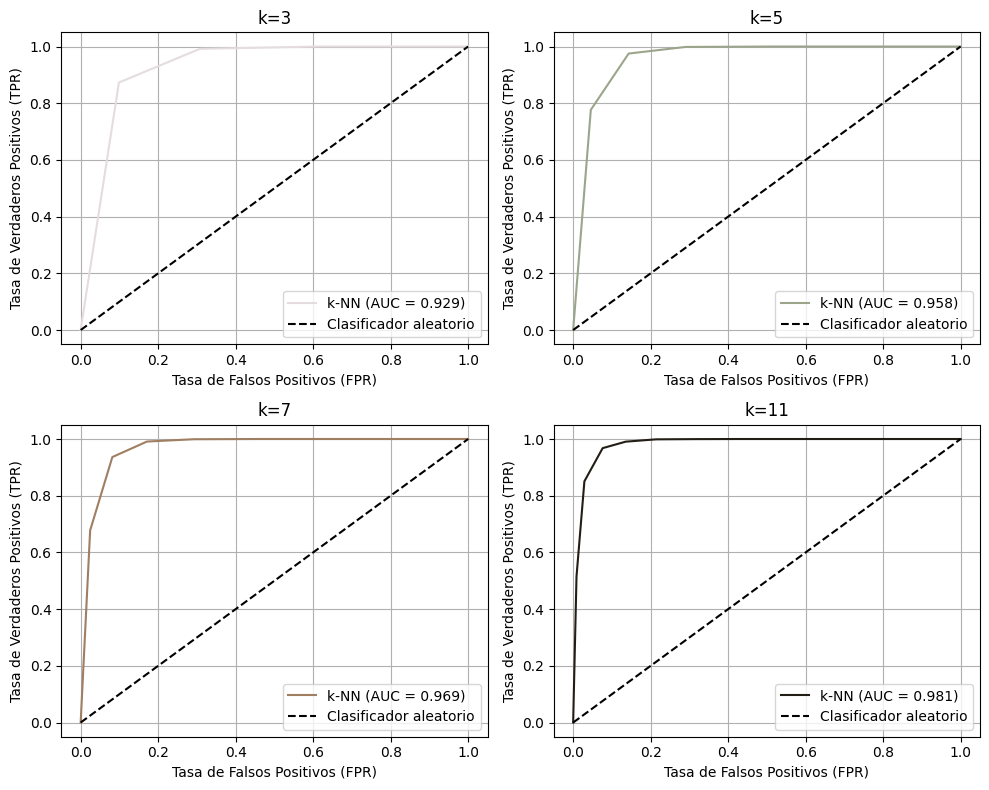

In [ ]:
# Graficar curva ROC en función de k
# Crear un mosaico de 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes      = axes.ravel() # ravel() convierte un array multiple en 1D

# Asignar títulos a cada sub-gráfica
titulos   = ['k=3', 'k=5', 'k=7', 'k=11']

# Graficar en un ciclo for
for i in np.arange(0, len(df_metricas_one_hot)):
    valor_auc = float(df_metricas_one_hot['AUC'][i]) # Obtener AUC en format float
    axes[i].plot(df_metricas_one_hot['FPR'][i], df_metricas_one_hot['TPR'][i], label=f'k-NN (AUC = {valor_auc:.3f})', color=np.random.rand(3,))
    axes[i].plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[i].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[i].legend()
    axes[i].grid(True)

# Mostrar gráfico
plt.tight_layout()
plt.show()

**About the results of the kNN model using one-hot encoding**

The model with k=5 shows the best overall performance with an error of 14.79% (accuracy of ~85.2%), closely followed by k=7 (error = 14.90%).  

All models achieve an AUC above 0.92, confirming their discriminative ability, with k=11 standing out (AUC = 0.9811). Additionally, there is a clear trend where the AUC improves (from 0.9289 to 0.9811) as k increases, though this involves balancing sensitivity (TPR) and false positives (FPR). For instance:  

- In applications where detecting most interactive peptides is the priority, k=5 (TPR=97.51%) or k=3 (TPR=99.18%) are solid options.  
- If the main objective is to minimize false positives, then k=11 (FPR=2.90%) is ideal.  

The class balance is clearly symmetrical, as shown in the following table, which validates the reliability of the accuracy and error metrics.

| **k** | **Positive Class (TP + FN)** | **Negative Class (TN + FP)** | **Total** | **% Positives** | **% Negatives** |
|-------|------------------------------|------------------------------|-----------|-----------------|-----------------|
| 3     | 2575                         | 2653                         | 5228      | 49.27%          | 50.73%          |
| 5     | 2575                         | 2653                         | 5228      | 49.27%          | 50.73%          |
| 7     | 2575                         | 2653                         | 5228      | 49.27%          | 50.73%          |
| 11    | 2575                         | 2653                         | 5228      | 49.27%          | 50.73%          |

Finally, the ROC curves, with their strongly convex shape toward the upper-left corner, reflect the models’ good quality.

## 7 Implementation of the kNN Algorithm Using Substitution Matrix Encoding

This section covers the implementation of the kNN algorithm for k = 3, 5, 7, and 11 using data encoded by the `matriz_trans_encoder()` function.  
The steps described are:  

- Implement the function `modelo_knn_ks()` to compute kNN for k = 3, 5, 7, and 11 on substitution matrix–encoded data.  
- Present the results of the kNN algorithm for k = 3, 5, 7, and 11 on substitution matrix–encoded data.

### 7.1 Implementing the function `modelo_knn_ks()` to compute kNN for k = 3, 5, 7, and 11

In [ ]:
# Guardar en un dataframe el contenido de peptidos.csv
df_peptidos = pd.read_csv("peptidos.csv", delimiter=';')

# Leer el archivo BLOSUM62_probabilities
blosum62prob_df = pd.read_csv("BLOSUM62_probabilities.csv", delimiter=';', dtype=str)

In [ ]:
# Codificar todas las secuencias de péptidos usando `matriz_trans_encoder()`
peptidos_encoded = matriz_trans_encoder(df_peptidos['sequence'], blosum62prob_df)

In [ ]:
# Convertir la columna label a binario
label_binario = df_peptidos['label'].apply(lambda x: 1 if x == 'SB' else 0)
# Convertir de pandas.Series a un array de Numpy
label_array = label_binario.to_numpy()

In [ ]:
# Comprobar que las variables del dataset se encuentren en el rango de (0,1) y que sean tipo array
# total_sequences_array_reshaped.shape = (15840, 180)
# labels.shape = (15840,)
print(f"La variable péptidos transformado por matriz de substitución es de tipo {type(peptidos_encoded)} con dimensión {peptidos_encoded.shape}\n"
      f"y la variable label es de tipo {type(label_array)} con dimensión {label_array.shape}")

La variable péptidos transformado por matriz de substitución es de tipo <class 'numpy.ndarray'> con dimensión (15840, 180)
y la variable label es de tipo <class 'numpy.ndarray'> con dimensión (15840,)


In [ ]:
# Crear train y test datasets
X_train, X_test, y_train, y_test = train_test_split(
    peptidos_encoded,
    label_array,
    test_size = 0.33, # 33% para el dataset test como lo indica el enunciado de la PEC1
    random_state= 123 # Fijamos la semilla aleatoria en 123
)

In [ ]:
# Visualizar la dimensiones de los 4 datases creados a partir de train_test_split()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10612, 180), (10612,), (5228, 180), (5228,))

In [ ]:
# Generar un dataframe con las métricas para cada valor de k
# Inicializar una lista que contenga las métricas
metricas = []

# Iterar por cada valor de k
for k in [3, 5, 7, 11]:
  tn, fp, fn, tp, error, fpr, tpr, thresholds, auc_score = modelo_knn_ks(k, X_train, y_train, X_test, y_test)
  metricas.append([k, tn, fp, fn, tp, error, fpr, tpr, thresholds, auc_score])

# Crear el dataframe de métricas
df_metricas_mat_sub = pd.DataFrame(metricas, columns=["k", "TN", "FP", "FN", "TP", "Error", "FPR", "TPR", "Thresholds", "AUC"])

### 7.2 Present the results of the kNN algorithm for k = 3, 5, 7, and 11

In [ ]:
# Visualizar métricas para cada valor de k
df_metricas_mat_sub

,k,TN,FP,FN,TP,Error,FPR,TPR,Thresholds,AUC
0,3,1850,803,10,2565,0.155509,"[0.0, 0.11307953260459856, 0.3026762156049755,...","[0.0, 0.9114563106796116, 0.996116504854369, 1...","[inf, 1.0, 0.6666666666666666, 0.3333333333333...",0.929167
1,5,1864,789,2,2573,0.151301,"[0.0, 0.061062947606483224, 0.1703731624575951...","[0.0, 0.8543689320388349, 0.9848543689320388, ...","[inf, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0]",0.955152
2,7,1834,819,0,2575,0.156656,"[0.0, 0.03392385978137957, 0.11307953260459856...","[0.0, 0.7794174757281553, 0.9689320388349515, ...","[inf, 1.0, 0.8571428571428571, 0.7142857142857...",0.967759
3,11,1786,867,0,2575,0.165838,"[0.0, 0.01620806633999246, 0.05352431209950999...","[0.0, 0.6667961165048544, 0.920388349514563, 0...","[inf, 1.0, 0.9090909090909091, 0.8181818181818...",0.978331


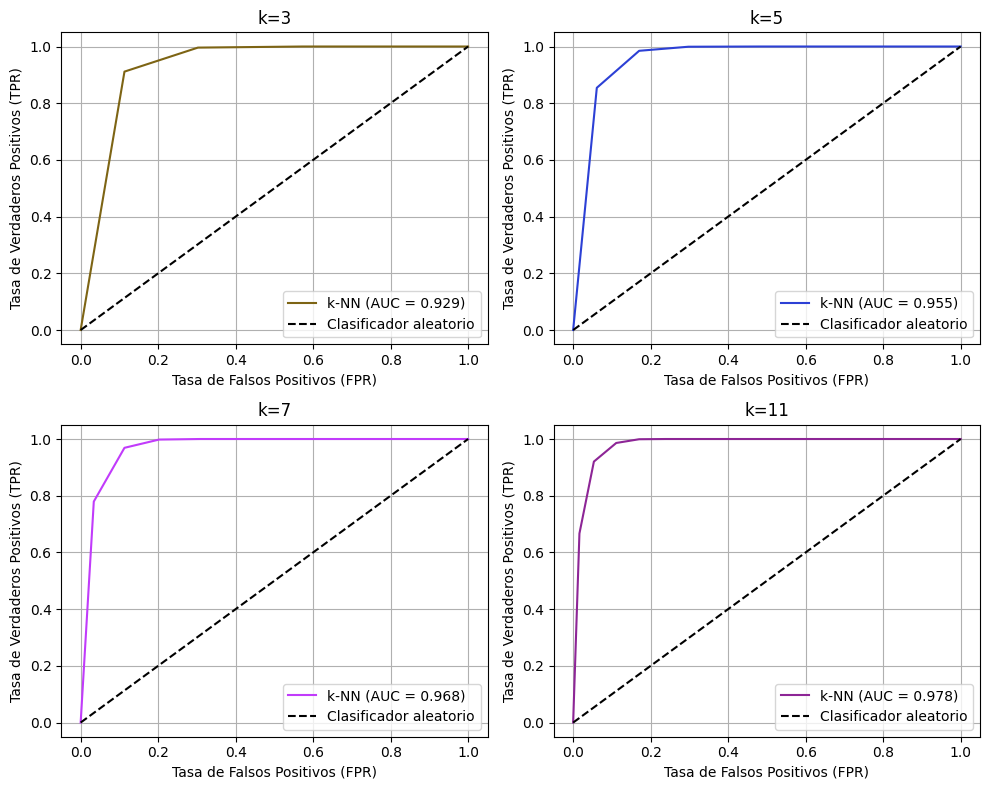

In [ ]:
# Graficar curva ROC en función de k
# Crear un mosaico de 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes      = axes.ravel() # ravel() convierte un array multiple en 1D

# Asignar títulos a cada sub-gráfica
titulos   = ['k=3', 'k=5', 'k=7', 'k=11']

# Graficar en un ciclo for
for i in np.arange(0, len(df_metricas_mat_sub)):
    valor_auc = float(df_metricas_mat_sub['AUC'][i]) # Obtener AUC en format float
    axes[i].plot(df_metricas_mat_sub['FPR'][i], df_metricas_mat_sub['TPR'][i], label=f'k-NN (AUC = {valor_auc:.3f})', color=np.random.rand(3,))
    axes[i].plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[i].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[i].legend()
    axes[i].grid(True)

# Mostrar gráfico
plt.tight_layout()
plt.show()

**About the results of the kNN model using substitution matrix encoding**

The accuracy of the four kNN models remains fairly stable at around 84–85%, with k=5 showing the best performance (error = 15.13%). Thus, k=5 or k=7 seem to be good choices for predicting whether a peptide sequence interacts with MHCI or not.  

All models have an AUC > 0.92, which reflects a strong discriminative capacity, with k=11 reaching the best AUC (0.9783). As observed earlier, AUC (from 0.929 to 0.978) improves as k increases.  

The following table shows there is no significant imbalance; the classes are nearly 50% each. This reinforces the reliability of the accuracy metric across the four models, which range between 84–85%.

| **k** | **Positive Class (TP + FN)** | **Negative Class (TN + FP)** | **Total** | **% Positives** | **% Negatives** |
|-------|------------------------------|------------------------------|-----------|-----------------|-----------------|
| 3     | 2575                         | 2653                         | 5228      | 49.3%           | 50.7%           |
| 5     | 2575                         | 2653                         | 5228      | 49.3%           | 50.7%           |
| 7     | 2575                         | 2653                         | 5228      | 49.3%           | 50.7%           |
| 11    | 2575                         | 2653                         | 5228      | 49.3%           | 50.7%           |

Finally, looking at the ROC curves for each k, they are all convex and clearly away from the diagonal. For instance, if one wanted to select a zone with high sensitivity, the model with k=11 would be a good choice, as it achieves a very low FPR=5.35% while detecting nearly all positives with few false positives.

## 8 Comparison of Classification Results Obtained with the Two Peptide Representation Techniques: One-Hot Encoding and Substitution Matrix Transformation (BLOSUM62)

The models using one-hot encoding show slightly better performance compared to those using substitution matrix encoding.  

- In terms of lowest error: **14.79% (one-hot)** vs. **15.13% (matrix)**.  
- In terms of AUC: **0.9811 (one-hot)** vs. **0.9783 (matrix)**.  

One-hot encoding provides greater accuracy and discriminative power, especially for detecting interactive peptides (high TPR). However, both methods maintain an AUC > 0.92 and class balance (~50%), which validates their reliability.  

These results suggest that the final choice of model should depend on the desired trade-off between sensitivity and specificity.

## References

- [Machine Learning for MHC I peptide classification](https://ab604.github.io/docs/mhc_tensorflow_notebook.html)